In [5]:
pip install -U wordcloud

  Using cached wordcloud-1.9.6-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (3.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.3/546.3 kB 8.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import RegexpTokenizer, word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import re
from wordcloud import WordCloud
from Sastrawi.Stemmer import StemmerFactory


In [2]:
df = pd.read_csv('../labeling/data_labeled.csv')

In [3]:
#Proses Tokenisasi
tokenizer = RegexpTokenizer(r'\w+')
df['stemming'] = df['stemming'].apply(lambda x: tokenizer.tokenize(x))

df

,stemming,inset,senti
0,"[chale, man, start, dey, crypto, football, ay,...",neg,neg
1,"[bitcoin, orange, ogsatoshis]",neg,neg
2,"[wahyus, problem, besar, selesai, web, risiko,...",neg,pos
3,"[boomer, bilang, underwear, eh, underlyingnya,...",neg,neg
4,"[ek, aisi, wife, main, bhi, deserve, karta, hu...",neg,neg
...,...,...,...
1231,"[raja, mata, uang, crypto, bitcoin, postingan,...",neg,neg
1232,"[ktk, kampuni, zenye, market, cap, kubwa, duni...",pos,neg
1233,"[meinmokhtar, hang, keje, penuh, asb, dah, n, ...",neg,pos
1234,"[join, gabung, ajar, santuy, bareng, cryptoriz...",neg,pos


In [4]:
print(df['inset'].value_counts())
print(df['senti'].value_counts())


inset
neg    836
pos    400
Name: count, dtype: int64
senti
neg    963
pos    273
Name: count, dtype: int64


In [5]:
x = df['stemming']
y = df['inset'] # atau df['senti'] untuk klasifikasi sentimen

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
print(f'Jumlah data latih x: {len(x_train)}\n', f'Jumlah data latih y: {len(y_train)}')
print(f'Jumlah data uji x: {len(x_test)}\n', f'Jumlah data uji y: {len(y_test)}')


Jumlah data latih x: 988
 Jumlah data latih y: 988
Jumlah data uji x: 248
 Jumlah data uji y: 248


In [6]:
y_test.value_counts()

inset
neg    161
pos     87
Name: count, dtype: int64

In [7]:
tfidf_vectorizer = TfidfVectorizer(analyzer=lambda x: x)

x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

print(x_train_tfidf, "\n")
print(x_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11483 stored elements and shape (988, 4722)>
  Coords	Values
  (0, 3849)	0.17517163811581168
  (0, 1640)	0.18138872531769398
  (0, 1140)	0.16579705738620382
  (0, 2890)	0.1894039447596956
  (0, 2374)	0.33159411477240763
  (0, 4642)	0.36277745063538797
  (0, 3901)	0.18138872531769398
  (0, 863)	0.20070076207564627
  (0, 1970)	0.20070076207564627
  (0, 272)	0.17517163811581168
  (0, 3051)	0.20070076207564627
  (0, 3711)	0.35034327623162337
  (0, 931)	0.1351882033123009
  (0, 496)	0.03721343248908119
  (0, 1342)	0.1620766885597417
  (0, 3502)	0.1558596013578594
  (0, 534)	0.20070076207564627
  (0, 657)	0.35034327623162337
  (0, 1641)	0.16579705738620382
  (0, 3830)	0.17517163811581168
  (0, 4546)	0.18138872531769398
  (1, 2183)	0.6674007372847831
  (1, 3760)	0.6674007372847831
  (1, 2926)	0.3303823720228662
  (2, 2321)	0.16915267047735985
  :	:
  (984, 4246)	0.1921706681593664
  (984, 198)	0.2754542416454851
  (984, 2508)	0.306

# __PEMODELAN SVM__

In [8]:
model = SVC()

params_grid = [{'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['linear']},
               {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['rbf'], 'gamma': [0.0001, 0.001, 0.01, 0.1]},
              {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['poly'], 'gamma': [0.0001, 0.001, 0.01, 0.1], 'degree': [2, 3, 4]}
              ]

params_grid

[{'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['linear']},
 {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000],
  'kernel': ['rbf'],
  'gamma': [0.0001, 0.001, 0.01, 0.1]},
 {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000],
  'kernel': ['poly'],
  'gamma': [0.0001, 0.001, 0.01, 0.1],
  'degree': [2, 3, 4]}]

## __Pemodelan SVM dengan Fungsi Kernel Linear__

In [9]:
grid_linear = GridSearchCV(estimator=model,
                           param_grid=params_grid[0],
                           scoring='accuracy')

#pelatihan model kernel linear
grid_linear.fit(x_train_tfidf, y_train)

print("Best parameters found: ", grid_linear.best_estimator_)
print(f"Best Score: {grid_linear.best_score_ * 100:.2f}%")

Best parameters found:  SVC(C=10, kernel='linear')
Best Score: 80.16%


## __Pemodelan SVM dengan Fungsi Kernel RBF__

In [10]:
grid_rbf = GridSearchCV(estimator=model,
                        param_grid=params_grid[1],
                        scoring='accuracy')
#pelatihan model kernel rbf
grid_rbf.fit(x_train_tfidf, y_train)

print("Best parameters found: ", grid_rbf.best_estimator_)
print(f"Best Score: {grid_rbf.best_score_ * 100:.2f} %")

Best parameters found:  SVC(C=1000, gamma=0.01)
Best Score: 80.06 %


## __Pemodelan SVM dengan Fungsi Kernel Poly__

In [11]:
grid_poly = GridSearchCV(estimator=model,
                         param_grid=params_grid[2],
                         scoring='accuracy')

##pelatihan model kernel polynomial
grid_poly.fit(x_train_tfidf, y_train)

print("Best parameters found: ", grid_poly.best_estimator_)
print(f"Best Score: {grid_poly.best_score_ * 100:.2f} %")

Best parameters found:  SVC(C=1000, degree=2, gamma=0.1, kernel='poly')
Best Score: 74.60 %


# __EVALUASI__

### __Counfussion Matrix Kernel Linear__

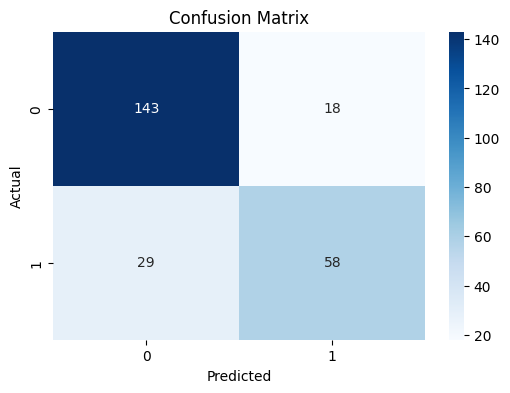

Confusion Matrix:
TP : 58
TN : 143
FP : 18
FN : 29


Classification Report:
              precision    recall  f1-score   support

         neg       0.83      0.89      0.86       161
         pos       0.76      0.67      0.71        87

    accuracy                           0.81       248
   macro avg       0.80      0.78      0.79       248
weighted avg       0.81      0.81      0.81       248

Nilai prediksi akurasi kernel linear:  81.04838709677419


In [15]:
# prediksi akurasi kernel linear 
y_pred_linear = grid_linear.best_estimator_.predict(x_test_tfidf)
akurasi_linear = accuracy_score(y_test, y_pred_linear)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print("TP :", cm[1][1])
print("TN :", cm[0][0])
print("FP :", cm[0][1])
print("FN :", cm[1][0])
print('\n')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_linear))
print("Nilai prediksi akurasi kernel linear: ", akurasi_linear * 100)

### __Confussion Matrix Kernel RBF__

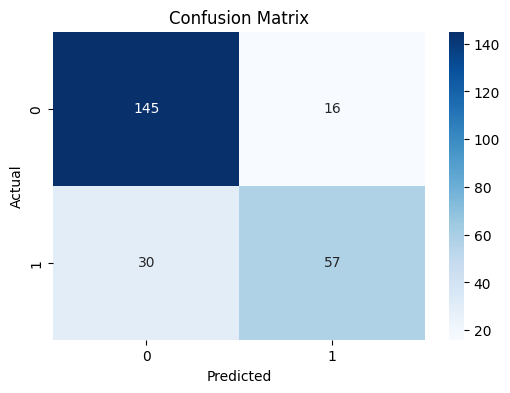

Classification Report:
              precision    recall  f1-score   support

         neg       0.83      0.90      0.86       161
         pos       0.78      0.66      0.71        87

    accuracy                           0.81       248
   macro avg       0.80      0.78      0.79       248
weighted avg       0.81      0.81      0.81       248

Nilai prediksi akurasi kernel rbf:  81.45161290322581


In [ ]:
y_pred_rbf = grid_rbf.best_estimator_.predict(x_test_tfidf)
akurasi_rbf = accuracy_score(y_test, y_pred_rbf)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print("TP :", cm[1][1])
print("TN :", cm[0][0])
print("FP :", cm[0][1])
print("FN :", cm[1][0])
print('\n')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rbf))
print("Nilai prediksi akurasi kernel rbf: ", akurasi_rbf * 100)

### __Confussion Matrix Kernel Polinomial__

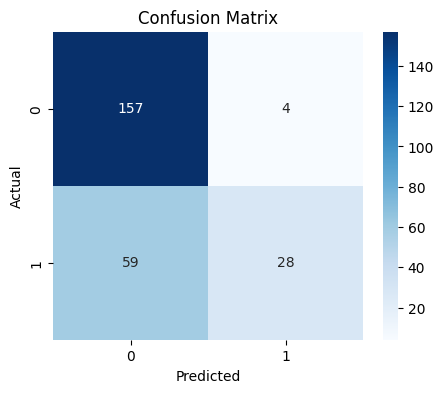

Confusion Matrix:
TP : 28
TN : 157
FP : 4
FN : 59


Classification Report:
              precision    recall  f1-score   support

         neg       0.73      0.98      0.83       161
         pos       0.88      0.32      0.47        87

    accuracy                           0.75       248
   macro avg       0.80      0.65      0.65       248
weighted avg       0.78      0.75      0.71       248

Nilai prediksi akurasi kernel poly:  74.59677419354838


In [14]:
y_pred_poly = grid_poly.best_estimator_.predict(x_test_tfidf)
akurasi_poly = accuracy_score(y_test, y_pred_poly)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_poly)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print("TP :", cm[1][1])
print("TN :", cm[0][0])
print("FP :", cm[0][1])
print("FN :", cm[1][0])
print('\n')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_poly))
print("Nilai prediksi akurasi kernel poly: ", akurasi_poly * 100)

Dari ketiga confusion matrix kernel berbeda, hasil matrix tersebut menunjukkan bahwa TP = 154, TN = 33, FP = 31, FN = 18